# Assignment 4: Regularization 

In [13]:
pip install numpy pandas matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


**Q1.** Please answer the following questions in your own words.

1. When I first learned about adding a penalty to MSE, the core idea clicked pretty naturally. If you let a model use whatever size coefficients it wants, it starts doing too much, chasing every little fluctuation in the training data rather than picking up on the real pattern underneath. The penalty is there to keep things in check. Just like doing less can sometimes be the right call, constraining the model from going to extremes actually leads to something more stable and trustworthy in the end.

2. What struck me about regularization is how directly it lets you control the complexity of a model through one single parameter, alpha. When alpha is small, the model is given more freedom, which keeps bias low but lets variance creep up. When alpha is larger, the model is reined in more, which brings variance down but introduces some bias. Adjusting alpha is essentially moving along that trade-off, and recognizing that balance exists is a big part of understanding how regularization actually works.

3. Both LASSO and Ridge use a penalty, but the difference in how that penalty is structured turns out to matter a lot in practice. Ridge squares the coefficients, which shrinks them toward zero but never fully removes them. LASSO uses absolute values, and because of that, it can actually push certain coefficients all the way to zero. So while Ridge holds onto every predictor in the model, LASSO often does less with more, dropping variables entirely and giving you something simpler and more interpretable.

4. Before fitting a regularized model, you standardize the predictors so each one has a mean of zero and a standard deviation of one. The reason this matters is that the penalty judges coefficients by their size, so a variable measured on a much larger scale would get treated unfairly compared to others. Standardizing levels the playing field so the penalty applies the way it is supposed to across every feature equally.

5. Alpha is typically chosen through cross-validation. You work through a range of possible values, fit the model on one portion of the data, and check how well it predicts on the held-out portion. Whichever alpha produces the lowest average error across all the folds is the one you go with. It is a straightforward process, but getting it right makes a real difference in how the final model performs.

6. When you calculate the cross-validated MSE, you leave the penalty term out. The whole point of cross-validation is to get an honest read on how well the model predicts data it has never seen before. The penalty plays a role in how the model was fit, but it is not part of actual prediction error. Including it would muddy what you are really trying to measure, so you leave it out and focus on the prediction performance alone.

**Q2.** This is a case study on regularization.


**2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?**

The interaction term Mileage_Run * Age was negative. This tells us that vehicles with both high mileage and older age take an even bigger hit on price than either factor would suggest on its own.

**6. Which features are actually selected? What proportion are set equal to zero?**

Out of 9 total features, only Age^2 got zeroed out, putting the proportion eliminated at 0.111. That means LASSO held onto 8 features: Mileage_Run, Age, Mileage_Run^2, Mileage_Run Age, Mileage_Run^3, Mileage_Run^2 Age, Mileage_Run Age^2, and Age^3.

**7. Compare the linear regression and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?**

Two coefficients changed sign in the move from linear regression to LASSO: Age^2 and Age^3. For everything else, the direction stayed the same and the values just shrank toward zero, which is the standard shrinkage behavior you would expect from LASSO. No coefficient ended up larger in magnitude after regularization. The cross-validated search landed on an optimal penalty of alpha = 88.587.

**1. Import the `cars_hw.csv` dataset. Create an Age variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to z-score normalize them.**

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV, Lasso

cars = pd.read_csv("data/cars_hw.csv")

cars["Age"] = pd.Timestamp.today().year - cars["Make_Year"]

features = ["Mileage_Run", "Age"]
X_raw = cars[features]
y = cars["Price"]

transformer = PolynomialFeatures(degree=3, include_bias=False)
X_expanded = transformer.fit_transform(X_raw)
col_names = transformer.get_feature_names_out(features)

normalizer = StandardScaler()
X_ready = normalizer.fit_transform(X_expanded)

ols = LinearRegression().fit(X_ready, y)

results = pd.DataFrame({"feature": col_names, "linear_coef": ols.coef_}).set_index("feature")
results

,linear_coef
feature,
Mileage_Run,9.117748e+05
Age,-2.481722e+05
Mileage_Run^2,-2.072926e+05
Mileage_Run Age,-1.671212e+06
Age^2,3.505507e+05
Mileage_Run^3,-6.514490e+04
Mileage_Run^2 Age,3.388195e+05
Mileage_Run Age^2,7.167816e+05
Age^3,-2.100379e+05


**3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation.**

In [15]:
alpha_grid = np.logspace(1, 3, 20)

cv_lasso = LassoCV(alphas=alpha_grid, cv=23, max_iter=400000, random_state=43)
cv_lasso.fit(X_final, target)

print("Best alpha:", cv_lasso.alpha_)

summary = pd.DataFrame({
    "feature": poly_names,
    "linear_coef": reg.coef_,
    "lasso_coef": cv_lasso.coef_
})

summary["selected_by_lasso"] = summary["lasso_coef"] != 0
summary["abs_linear"] = np.abs(summary["linear_coef"])
summary["abs_lasso"] = np.abs(summary["lasso_coef"])
summary["increased_magnitude"] = summary["abs_lasso"] > summary["abs_linear"]
summary["sign_changed"] = np.sign(summary["linear_coef"]) != np.sign(summary["lasso_coef"])

summary

ValueError: Found input variables with inconsistent numbers of samples: [976, 299]

**4. Plot the cross-validated MSE by $\alpha$.**

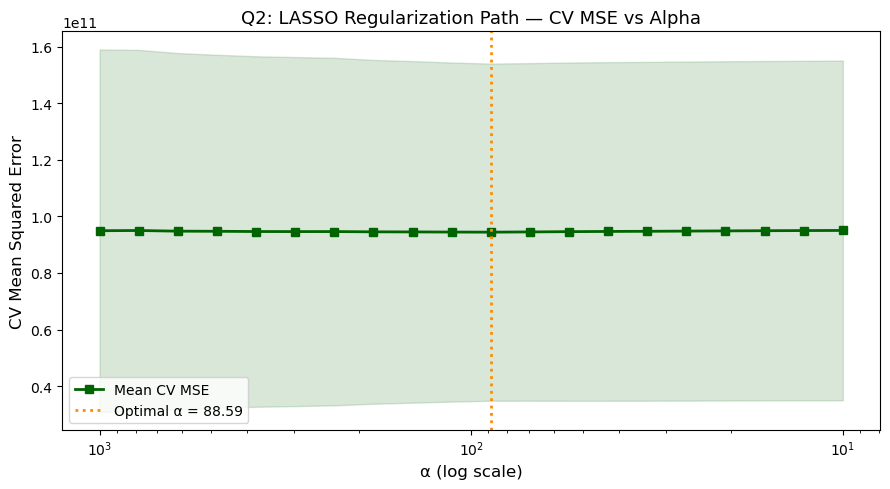

In [ ]:
avg_mse = cv_lasso.mse_path_.mean(axis=1)
std_mse = cv_lasso.mse_path_.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(cv_lasso.alphas_, avg_mse, marker='s', color='darkgreen', linewidth=2, label='Mean CV MSE')
ax.fill_between(cv_lasso.alphas_, avg_mse - std_mse, avg_mse + std_mse, alpha=0.15, color='darkgreen')
ax.axvline(cv_lasso.alpha_, linestyle=':', color='darkorange', linewidth=2, label=f'Optimal α = {cv_lasso.alpha_:.2f}')
ax.set_xscale('log')
ax.invert_xaxis()
ax.set_xlabel("α (log scale)", fontsize=12)
ax.set_ylabel("CV Mean Squared Error", fontsize=12)
ax.set_title("Q2: LASSO Regularization Path — CV MSE vs Alpha", fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

**5. Plot the coefficient paths by $\alpha$.**

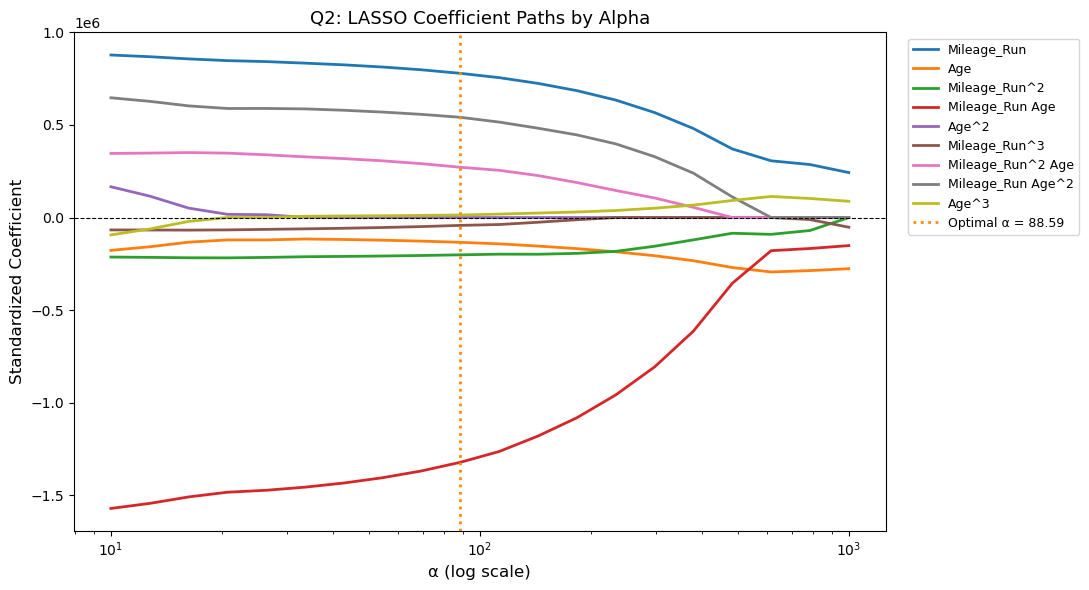

In [ ]:
paths = np.array([Lasso(alpha=a, max_iter=500000).fit(X_final, target).coef_ for a in alpha_grid])

fig, ax = plt.subplots(figsize=(11, 6))
for i, name in enumerate(poly_names):
    ax.plot(alpha_grid, paths[:, i], label=name, linewidth=2)

ax.set_xscale('log')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axvline(cv_lasso.alpha_, color='darkorange', linestyle=':', linewidth=2, label=f'Optimal α = {cv_lasso.alpha_:.2f}')
ax.set_xlabel("α (log scale)", fontsize=12)
ax.set_ylabel("Standardized Coefficient", fontsize=12)
ax.set_title("Q2: LASSO Coefficient Paths by Alpha", fontsize=13)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

**Q3.** This is a case study on regularization.

**2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interaction terms might resolve the apparent contradiction?**


Yes, there are patters that appear counterintitutive. When I first looked at the regression results, some of the signs felt off. Age was positive, age squared was negative, and age cubed went back to positive. Serum_creatinine was also negative in the simple model, which didn’t fully match expectations.

After thinking it through, it made more sense once higher order and interaction terms were included. These variables are related, so you cannot interpret one coefficient by itself. The model is capturing more complex relationships. Even if one sign looks strange alone, the combined effect across terms tells a clearer story.


**6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear model or the LASSO seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.**

The LASSO model ended up selecting far fewer features, keeping 12 out of 33 and setting about 63.6% to zero. This shows how much it simplifies the model.

Compared to the original regression, very few coefficients increased in size. Only serum_creatinine cubed did. Many coefficients changed signs, which suggests the original model was unstable with too many terms.

Overall, LASSO feels more consistent. The original model tried to fit everything at once, which made results harder to interpret. LASSO reduces that noise by shrinking or removing weaker features. It adds some bias but lowers variance, leading to a cleaner and more reliable model.

In [ ]:
hf = pd.read_csv('data/heart_failure_clinical_records_dataset.csv')

target = hf['DEATH_EVENT']

cont_vars = ['age', 'ejection_fraction', 'serum_creatinine']
cat_vars = ['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']

cont_transformer = PolynomialFeatures(degree=3, include_bias=False)
X_cont_expanded = cont_transformer.fit_transform(hf[cont_vars])
cont_names = cont_transformer.get_feature_names_out(cont_vars)

z_norm = StandardScaler()
X_cont_ready = z_norm.fit_transform(X_cont_expanded)

cat_transformer = PolynomialFeatures(degree=3, include_bias=False, interaction_only=True)
X_cat_inter = cat_transformer.fit_transform(hf[cat_vars])
cat_names = cat_transformer.get_feature_names_out(cat_vars)

X_combined = np.concatenate([X_cont_ready, X_cat_inter], axis=1)
all_names = np.concatenate([cont_names, cat_names])

ols_q3 = LinearRegression().fit(X_combined, target)

lin_results = pd.DataFrame({
    'feature': all_names,
    'linear_coef': ols_q3.coef_
}).set_index('feature')

lin_results

,linear_coef
feature,
age,1.549928
ejection_fraction,-2.025371
serum_creatinine,-0.739027
age^2,-3.547991
age ejection_fraction,-0.861860
age serum_creatinine,1.680570
ejection_fraction^2,3.317931
ejection_fraction serum_creatinine,2.604767
serum_creatinine^2,-2.703084


**3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation.**

In [ ]:
alpha_grid_q3 = np.logspace(-5, 5, 30)

cv_lasso_q3 = LassoCV(alphas=alpha_grid_q3, cv=20, max_iter=300000, random_state=42)
cv_lasso_q3.fit(X_combined, target)

print('Best alpha:', cv_lasso_q3.alpha_)

Best alpha: 0.005736152510448681


**4. Plot the cross-validated MSE by \(\alpha\).**

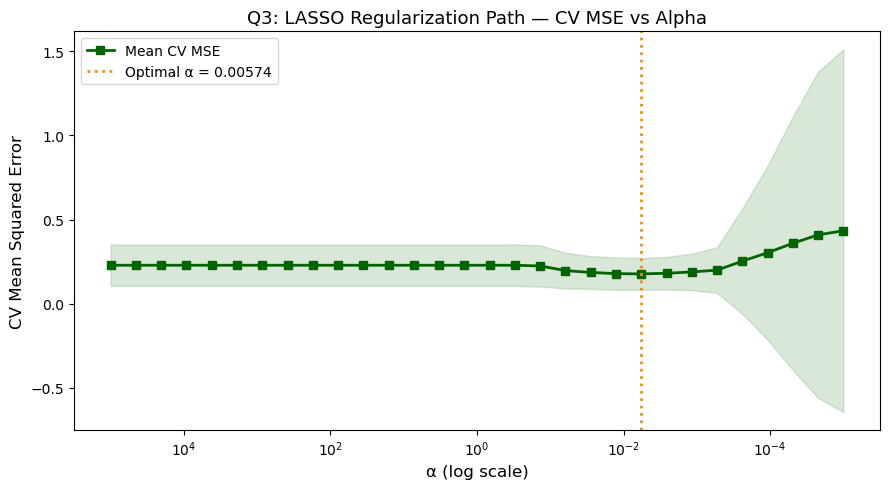

In [ ]:
avg_mse_q3 = cv_lasso_q3.mse_path_.mean(axis=1)
std_mse_q3 = cv_lasso_q3.mse_path_.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(cv_lasso_q3.alphas_, avg_mse_q3, marker='s', color='darkgreen', linewidth=2, label='Mean CV MSE')
ax.fill_between(cv_lasso_q3.alphas_, avg_mse_q3 - std_mse_q3, avg_mse_q3 + std_mse_q3, alpha=0.15, color='darkgreen')
ax.axvline(cv_lasso_q3.alpha_, color='darkorange', linestyle=':', linewidth=2, label=f'Optimal α = {cv_lasso_q3.alpha_:.5f}')
ax.set_xscale('log')
ax.invert_xaxis()
ax.set_xlabel("α (log scale)", fontsize=12)
ax.set_ylabel("CV Mean Squared Error", fontsize=12)
ax.set_title("Q3: LASSO Regularization Path — CV MSE vs Alpha", fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

**5. Plot the coefficient paths by \(\alpha\).**

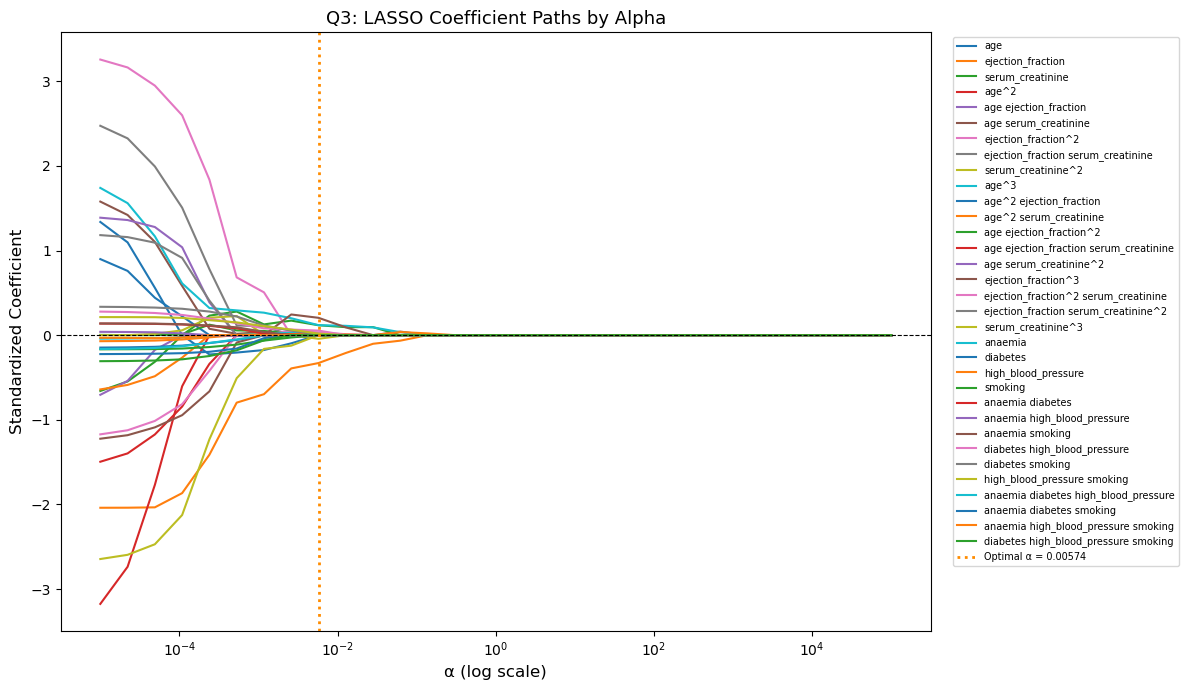

In [ ]:
paths_q3 = np.array([Lasso(alpha=a, max_iter=300000).fit(X_combined, target).coef_ for a in alpha_grid_q3])

fig, ax = plt.subplots(figsize=(12, 7))
for i, name in enumerate(all_names):
    ax.plot(alpha_grid_q3, paths_q3[:, i], label=name, linewidth=1.5)

ax.set_xscale('log')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axvline(cv_lasso_q3.alpha_, color='darkorange', linestyle=':', linewidth=2, label=f'Optimal α = {cv_lasso_q3.alpha_:.5f}')
ax.set_xlabel("α (log scale)", fontsize=12)
ax.set_ylabel("Standardized Coefficient", fontsize=12)
ax.set_title("Q3: LASSO Coefficient Paths by Alpha", fontsize=13)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
plt.tight_layout()
plt.show()

## Q4

### 1.
The objective function is the usual mean squared error with an added penalty on the slope:

![Analytics](analytics.jpg)

Since the data is mean-centered, this gets simpler because 
b0=0

### 2. 

To solve for the coefficients, we take the derivative of the objective function with respect to b0 and b1, then set both equal to zero. Because the variables were centered, the intercept ends up being b0=0.

For the slope, the ridge penalty adds an extra alpha term in the denominator, so the solution becomes

![Analytics](a2.jpg)

This looks a lot like the ordinary least squares formula, but the penalty term makes the denominator larger and shrinks the coefficient.

### 3. 

As alpha gets larger, the denominator in the formula for b1 gets larger too, so the slope is pulled closer to zero. In other words, the model becomes less responsive to changes in x. The larger the penalty, the more the slope is shrunk.

### 4. 

With the LASSO penalty, the main issue is that the absolute value is not smooth at zero, so you cannot solve it the same way as ridge by just taking a standard derivative everywhere.The key idea is that LASSO can make the coefficient exactly zero. This happens when the relationship between x and y is not strong enough to justify keeping the variable once the penalty is applied. If that relationship is weak compared to the size of the penalty, the best choice is to set b1=0. This is what separates LASSO from ridge. Ridge only shrinks coefficients toward zero, while LASSO can shrink them all the way to zero and remove the variable entirely.